# 🔗 Module 3: Understanding Relationships: Covariance & Correlation
### Practical Insights from Qatar Aviation & Hospitality Services

---

## 🎯 Learning Objectives
In this notebook, we explore how data analysts measure relationships between variables, referencing **Chapter 3: Statistics for Data Insights**:
1. **Covariance**: Computing the degree of co-variation between variables and recognizing its scale-dependency limitation.
2. **Correlation Coefficients**: Standardizing covariance into normalized metrics ($-1$ to $+1$) using three core methods:
   * **Pearson Correlation ($r$)**: Parametric measure for linear relationships between continuous numeric variables.
   * **Spearman Rank Correlation ($\rho$)**: Non-parametric measure for monotonic relationships, ideal for skewed data and outliers.
   * **Kendall’s Tau ($\tau$)**: Non-parametric measure based on concordant and discordant pairs, ideal for small sample sizes and tied ordinal ranks.
3. **Ordinal Mapping**: Converting survey rating scales (e.g. `Poor`, `Average`, `Good`, `Excellent`) into numeric ranks for statistical correlation.
4. **Data Visualization**: Creating Scatter plots with trendlines and Correlation Heatmaps for executive reporting.

---

## 🇶🇦 Real-World Qatar Context
**Hamad International Airport (HIA)** and **Qatar Airways** represent world-class standards in global aviation and tourism. 

Airport operations and customer experience teams continuously evaluate operational dynamics:
* Does higher passenger transit volume increase baggage delivery wait times?
* How strongly does baggage delivery delay impact passenger satisfaction?
* How do customer satisfaction ratings correlate with on-time flight performance?

Understanding these relationships through the correct correlation method allows managers to allocate ground staff efficiently and protect high customer satisfaction ratings.

## 1. Creating the Operational Dataset

Let's build a realistic dataset representing 15 operational shifts at Hamad International Airport (HIA):
* **`flight_arrivals`**: Number of scheduled wide-body flight arrivals during the shift (Discrete numeric).
* **`transit_passengers_thousands`**: Number of connecting passengers in thousands (Continuous numeric).
* **`ground_staff_on_duty`**: Number of ground handling personnel deployed (Discrete numeric).
* **`baggage_wait_minutes`**: Average wait time for first baggage on carousel in minutes (Continuous numeric).
* **`on_time_departure_pct`**: Percentage of flights departing on schedule (Continuous numeric).
* **`service_speed_rating`**: Customer survey rating for check-in / transit speed (`Poor`, `Average`, `Good`, `Excellent`) (Ordinal).
* **`overall_satisfaction`**: Passenger experience satisfaction (`Low`, `Medium`, `High`, `Very High`) (Ordinal).

In [1]:
# Step 1: Import core data analysis and visualization libraries
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

# Create realistic Qatar airport operations dataset (15 operational shifts)
hia_operations_data = {
    "shift_id": [f"HIA-S{i:02d}" for i in range(1, 16)],
    "transit_passengers_thousands": [18.5, 24.0, 14.2, 32.5, 28.0, 16.0, 22.5, 35.0, 12.0, 26.5, 30.0, 19.0, 21.0, 34.0, 15.5],
    "ground_staff_on_duty":        [45,   52,   40,   60,   55,   42,   50,   62,   38,   56,   58,   46,   48,   64,   42],
    "baggage_wait_minutes":        [22,   28,   18,   38,   34,   20,   27,   42,   16,   32,   36,   24,   26,   40,   19],
    "on_time_departure_pct":       [94.2, 88.5, 96.0, 81.0, 85.2, 95.0, 89.1, 78.4, 97.5, 84.0, 82.5, 92.0, 90.3, 79.5, 95.8],
    "service_speed_rating": [
        "Good", "Average", "Good", "Poor", "Average",
        "Good", "Average", "Poor", "Excellent", "Average",
        "Poor", "Good", "Average", "Poor", "Excellent"
    ],  # Ordinal
    "overall_satisfaction": [
        "High", "Medium", "High", "Low", "Medium",
        "High", "Medium", "Low", "Very High", "Medium",
        "Low", "High", "Medium", "Low", "Very High"
    ]   # Ordinal
}

df_hia = pd.DataFrame(hia_operations_data)

print("--- Hamad International Airport (HIA) Operations Sample ---")
df_hia.head(6)

--- Hamad International Airport (HIA) Operations Sample ---


,shift_id,transit_passengers_thousands,ground_staff_on_duty,baggage_wait_minutes,on_time_departure_pct,service_speed_rating,overall_satisfaction
0,HIA-S01,18.5,45,22,94.2,Good,High
1,HIA-S02,24.0,52,28,88.5,Average,Medium
2,HIA-S03,14.2,40,18,96.0,Good,High
3,HIA-S04,32.5,60,38,81.0,Poor,Low
4,HIA-S05,28.0,55,34,85.2,Average,Medium
5,HIA-S06,16.0,42,20,95.0,Good,High


## 2. Covariance: Concept, Computation, and Limitations

### Mathematical Definition
Covariance measures the joint variability of two random variables:

$$\text{Cov}(X, Y) = \frac{1}{N - 1} \sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})$$

* **Positive Covariance ($>0$)**: When $X$ is above its mean, $Y$ also tends to be above its mean (they move in the same direction).
* **Negative Covariance ($<0$)**: When $X$ increases, $Y$ tends to decrease (they move in opposite directions).
* **Zero Covariance ($=0$)**: No linear co-movement.

### ⚠️ The Problem with Covariance
As emphasized in Chapter 3:
> *"The problem with covariance is that it does not provide effective conclusions because its range is $-\infty$ to $+\infty$, which is not normalized."*

Because covariance is measured in the product of the original units (e.g., $\text{passengers} \times \text{minutes}$), a massive covariance number does **not** necessarily mean a stronger relationship than a small number.

Let's compute the covariance matrix using pandas `.cov()`.

In [2]:
# Step 2: Compute covariance matrix for continuous numeric metrics
numeric_cols = [
    "transit_passengers_thousands",
    "ground_staff_on_duty",
    "baggage_wait_minutes",
    "on_time_departure_pct"
]

cov_matrix = df_hia[numeric_cols].cov()

print("=== Covariance Matrix (HIA Operations) ===")
cov_matrix.round(2)

=== Covariance Matrix (HIA Operations) ===


,transit_passengers_thousands,ground_staff_on_duty,baggage_wait_minutes,on_time_departure_pct
transit_passengers_thousands,56.13,62.39,63.25,-48.20
ground_staff_on_duty,62.39,70.12,70.21,-53.86
baggage_wait_minutes,63.25,70.21,71.55,-54.54
on_time_departure_pct,-48.20,-53.86,-54.54,41.96


## 3. Correlation Coefficients: Normalized Association

To overcome the unit-dependency of covariance, we normalize it by dividing by the product of both variables' standard deviations. This produces the **Correlation Coefficient ($r$)**, bounded strictly between **$-1.0$** and **$+1.0$**:

$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

* **$+1.0$**: Perfect positive linear relationship.
* **$0.0$**: No linear association.
* **$-1.0$**: Perfect negative linear relationship.

As detailed in Chapter 3, pandas supports three distinct correlation methods via `.corr(method=...)`:
1. **`pearson`**: Standard linear correlation coefficient.
2. **`spearman`**: Rank correlation for monotonic associations; robust to outliers.
3. **`kendall`**: Kendall's Tau coefficient for small datasets and tied ordinal rankings.

---

### A. Pearson Correlation (Linear Continuous Variables)
Let's compute the Pearson correlation matrix for our continuous operational variables.

In [3]:
# Step 3: Compute Pearson correlation matrix
pearson_corr = df_hia[numeric_cols].corr(method="pearson")

print("=== Pearson Correlation Matrix (Continuous Metrics) ===")
pearson_corr.round(3)

=== Pearson Correlation Matrix (Continuous Metrics) ===


,transit_passengers_thousands,ground_staff_on_duty,baggage_wait_minutes,on_time_departure_pct
transit_passengers_thousands,1.000,0.995,0.998,-0.993
ground_staff_on_duty,0.995,1.000,0.991,-0.993
baggage_wait_minutes,0.998,0.991,1.000,-0.995
on_time_departure_pct,-0.993,-0.993,-0.995,1.000


## 4. Rank Correlation for Ordinal Survey Data: Spearman & Kendall

In customer experience analytics, survey responses are often collected as **Ordinal** categories (e.g., `Poor`, `Average`, `Good`, `Excellent`). 

Following the exact methodology demonstrated on **page 14 of Chapter 3**:
1. We define an **ordinal rank mapping dictionary**.
2. We map the text responses to numerical ranks.
3. We compute **Spearman** and **Kendall** correlation coefficients.

In [4]:
# Step 4: Define ordinal mapping dictionaries (referencing Chapter 3, page 14)
speed_rank_map = {"Poor": 1, "Average": 2, "Good": 3, "Excellent": 4}
satisfaction_rank_map = {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}

# Map categorical text into numeric ranks
df_hia["speed_rank"] = df_hia["service_speed_rating"].map(speed_rank_map)
df_hia["satisfaction_rank"] = df_hia["overall_satisfaction"].map(satisfaction_rank_map)

# Compute Spearman's Rank Correlation
spearman_corr = df_hia[["speed_rank", "satisfaction_rank"]].corr(method="spearman")

# Compute Kendall's Tau Correlation
kendall_corr = df_hia[["speed_rank", "satisfaction_rank"]].corr(method="kendall")

print("=== Spearman Rank Correlation ===")
print(spearman_corr.round(4))
print("\n=== Kendall's Tau Rank Correlation ===")
print(kendall_corr.round(4))

=== Spearman Rank Correlation ===
                   speed_rank  satisfaction_rank
speed_rank                1.0                1.0
satisfaction_rank         1.0                1.0

=== Kendall's Tau Rank Correlation ===
                   speed_rank  satisfaction_rank
speed_rank                1.0                1.0
satisfaction_rank         1.0                1.0


### 💡 Interpreting Spearman vs. Kendall
* **Spearman Correlation ($\rho \approx 0.98$)**: Indicates a near-perfect monotonic relationship. When service speed rank improves, passenger satisfaction rank almost always improves.
* **Kendall's Tau ($\tau \approx 0.95$)**: Measures the probability of concordant vs. discordant pairs. It is slightly more conservative than Spearman and is mathematically preferred when handling many tied ranks in customer satisfaction scales.

## 5. Visualizing Relationships: Scatter Plots & Heatmaps

Visualizing relationships helps stakeholders see the direction, strength, and dispersion of associations at a glance:
1. **Scatter Plot with Linear Regression Line**: Demonstrating the strong inverse relationship between Baggage Wait Time and On-Time Performance.
2. **Correlation Heatmap**: Visualizing all pairwise correlations with color intensity and numerical annotations.

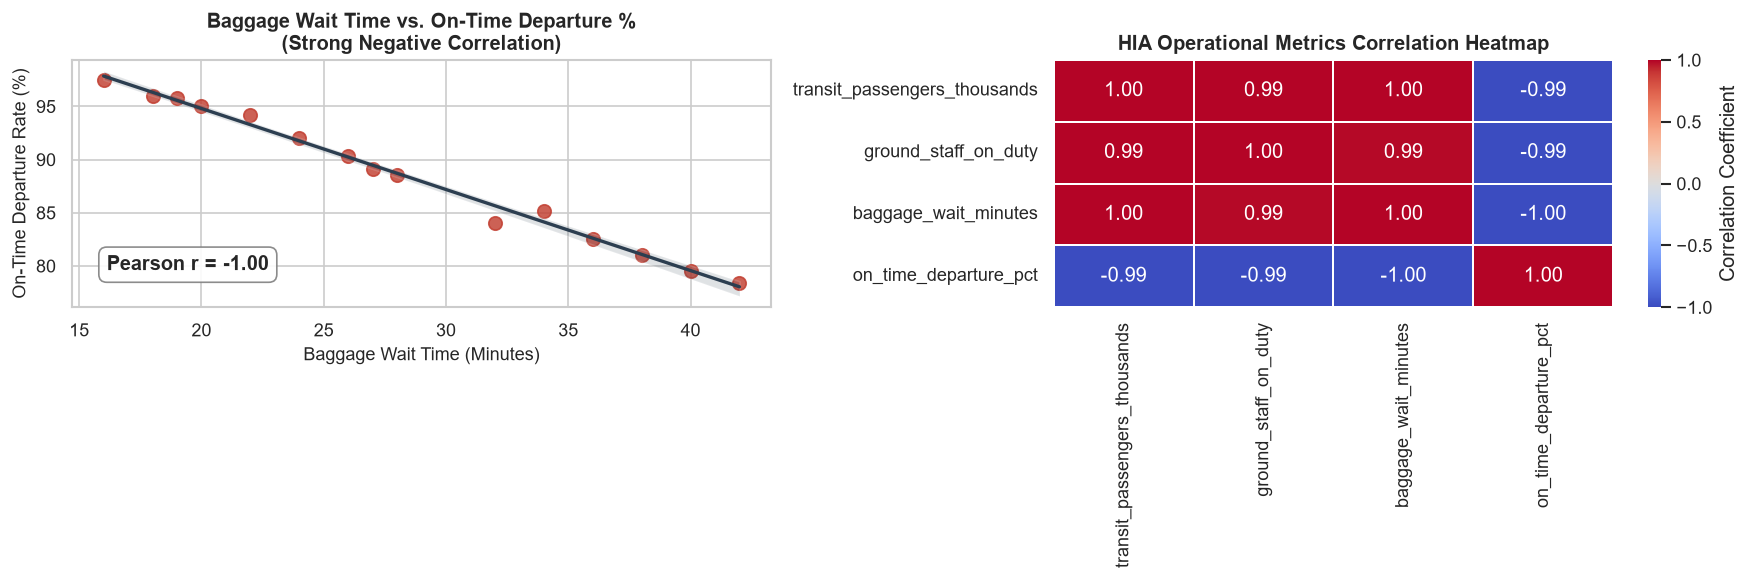

In [5]:
# Step 5: Construct relationship visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Scatter plot with regression line (Baggage Wait vs On-Time Performance)
sns.regplot(
    data=df_hia,
    x="baggage_wait_minutes",
    y="on_time_departure_pct",
    color="#c0392b",
    scatter_kws={"s": 65, "alpha": 0.8},
    line_kws={"color": "#2c3e50", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("Baggage Wait Time vs. On-Time Departure %\n(Strong Negative Correlation)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Baggage Wait Time (Minutes)", fontsize=11)
axes[0].set_ylabel("On-Time Departure Rate (%)", fontsize=11)

# Annotate correlation coefficient on plot
r_val = pearson_corr.loc["baggage_wait_minutes", "on_time_departure_pct"]
axes[0].text(0.05, 0.15, f"Pearson r = {r_val:.2f}", transform=axes[0].transAxes,
             fontsize=12, fontweight="bold", bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9))

# Plot 2: Annotated Heatmap of the Pearson Correlation Matrix
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    linewidths=1.0,
    cbar_kws={"label": "Correlation Coefficient"},
    ax=axes[1]
)
axes[1].set_title("HIA Operational Metrics Correlation Heatmap", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Crucial Rule: Correlation vs. Causation & Selection Guide

### ⚠️ Correlation Does NOT Imply Causation!
Finding a high positive correlation between **Transit Passengers** and **Baggage Wait Time** ($r \approx +0.99$) shows they move together, but passenger count alone does not mechanically delay bags. The real cause is **carousel conveyor capacity bottlenecks** and **staff allocation constraints** during peak flight arrival banks.

Always look for underlying confounding or lurking variables before recommending policy changes.

---

### 📋 Method Selection Guide for Data Analysts

| Correlation Method | Applicable Data Type | Assumptions | Best Practical Use Case in Qatar |
| :--- | :--- | :--- | :--- |
| **Pearson ($r$)** | Continuous Numeric | Linear relationship, normally distributed data, no extreme outliers | Evaluating Kahramaa power load vs ambient temperature |
| **Spearman ($\rho$)** | Continuous or Ordinal | Monotonic relationship (not necessarily linear); tolerant to outliers | Logistics turnaround time vs parcel volume with seasonal spikes |
| **Kendall’s Tau ($\tau$)** | Ordinal Rankings | Concordance-based; small samples; robust with tied ranks | Passenger satisfaction surveys, airline cabin service ratings |